### Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to characterize the curated MDM2 dataset before downstream modelling. The analysis focused on activity distribution, structural diversity, physicochemical properties, and their relationship with pIC50.

#### Activity-class distribution

Compounds were categorized as active, intermediate, or inactive according to their pIC50 values.

The dataset showed a strong imbalance toward active compounds:

- **Active:** 3,633 compounds (87.6%)
- **Intermediate:** 324 compounds (7.8%)
- **Inactive:** 189 compounds (4.6%)

This indicates that the available MDM2 bioactivity data are strongly enriched in potent compounds. For the regression analysis, this imbalance was treated as a characteristic of the available potency distribution rather than corrected by resampling.

#### Bemis–Murcko scaffold analysis

Bemis–Murcko scaffolds were generated from the standardized molecular structures to examine structural diversity within the dataset.

All **4,146 compounds** produced valid Bemis–Murcko scaffolds. A total of **1,486 unique scaffolds** were identified, corresponding to an average of approximately **2.79 compounds per scaffold**.

The large number of unique scaffolds relative to the total number of compounds indicates substantial structural diversity in the MDM2 dataset.

#### Singleton scaffolds

A singleton scaffold was defined as a Bemis–Murcko scaffold represented by only one compound.

A total of **957 singleton scaffolds** were identified. These accounted for:

- **64.4% of all unique scaffold types**
- **23.1% of all compounds in the dataset**

The high proportion of singleton scaffolds indicates that many compounds possess distinct core structures rather than belonging to a small number of highly repetitive structural families. This supports the use of scaffold-based splitting to provide a more challenging and realistic assessment of model generalization to structurally different compounds.

#### Scaffold frequency

Although many scaffolds occurred only once, several larger analogue series were also present. The most frequent scaffold contained **112 compounds**, while other common scaffolds were represented by smaller groups.

Overall, the scaffold analysis indicates that the dataset contains both repeated chemical series and a large number of structurally distinct compounds, providing relatively broad structural coverage for QSAR modelling.

#### Physicochemical analysis

Selected physicochemical descriptors were calculated using RDKit, including molecular weight (MW), LogP, TPSA, hydrogen-bond donors (HBD), hydrogen-bond acceptors (HBA), and rotatable bonds.

Boxplot analysis showed substantial overlap in these properties between active, intermediate, and inactive compounds. Therefore, no individual simple physicochemical descriptor clearly separated the three activity classes.

#### Correlation with pIC50

Pearson correlation analysis showed that the selected physicochemical descriptors had only weak linear relationships with pIC50. This indicates that MDM2 inhibitory potency cannot be explained by a single simple molecular property.

The weak descriptor–pIC50 correlations support the use of richer molecular representations, including PaDEL descriptors and Morgan fingerprints, together with nonlinear machine-learning models for potency prediction.

#### EDA conclusion

Overall, the curated MDM2 dataset is strongly enriched in active compounds but contains substantial scaffold diversity. The high number of unique and singleton scaffolds demonstrates broad structural coverage, while the physicochemical analysis shows that simple molecular properties alone are insufficient to explain MDM2 potency. These observations support scaffold-aware data splitting and the use of multivariate molecular representations in subsequent QSAR modelling.

## Step 1: IMPORTS AND NOTEBOOK SETUP


In [1]:
# ============================================================
# NOTEBOOK 04 — MDM2 pIC50 EXPLORATORY DATA ANALYSIS
# STEP 1: IMPORTS AND NOTEBOOK SETUP
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED
from rdkit.Chem.Scaffolds import MurckoScaffold


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42


print("Imports completed successfully.")

Imports completed successfully.


## Step 2: DEFINE FILE PATHS


In [2]:
# ============================================================
# STEP 2: DEFINE FILE PATHS
# ============================================================

DATA_PATH = Path(
    "data/processed/mdm2_pic50_qsar_standardized.csv"
)

OUTPUT_DIR = Path(
    "results/notebook04_eda"
)

FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


print("Input file:")
print(DATA_PATH)

print("\nOutput directory:")
print(OUTPUT_DIR)

Input file:
data/processed/mdm2_pic50_qsar_standardized.csv

Output directory:
results/notebook04_eda


## Step 3 — Load the final standardized QSAR dataset

In [7]:
# ============================================================
# STEP 3: LOAD FINAL STANDARDIZED QSAR DATASET
# ============================================================

from pathlib import Path
import pandas as pd

DATA_PATH = Path(
    "/Users/maryta/Downloads/mdm2_Reinvent_4/"
    "data/processed/mdm2_pic50_qsar_standardized.csv"
)

print("File exists:", DATA_PATH.exists())
print("Path:", DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

File exists: True
Path: /Users/maryta/Downloads/mdm2_Reinvent_4/data/processed/mdm2_pic50_qsar_standardized.csv

Dataset loaded successfully.
Shape: (4146, 9)


,molecule_chembl_id,canonical_smiles,standardized_smiles,IC50_nM_median,pIC50,pIC50_mean,pIC50_std,measurement_count,bioactivity_class
0,CHEMBL5986166,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,34.24,7.465466,7.465466,NaN,1,active
1,CHEMBL5741921,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,7.65,8.116422,8.116422,NaN,4,active
2,CHEMBL4865855,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,11.00,7.958607,7.958607,NaN,3,active
3,CHEMBL5821902,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,5.20,8.283997,8.283997,NaN,3,active
4,CHEMBL5825373,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,5.20,8.283997,8.283997,NaN,1,active


## Step 4 — Inspect columns and basic structure

In [8]:
# ============================================================
# STEP 4: INSPECT DATASET STRUCTURE
# ============================================================

print("Columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

Columns:
 1. molecule_chembl_id
 2. canonical_smiles
 3. standardized_smiles
 4. IC50_nM_median
 5. pIC50
 6. pIC50_mean
 7. pIC50_std
 8. measurement_count
 9. bioactivity_class

Dataset shape:
(4146, 9)

Data types:


,dtype
molecule_chembl_id,str
canonical_smiles,str
standardized_smiles,str
IC50_nM_median,float64
pIC50,float64
pIC50_mean,float64
pIC50_std,float64
measurement_count,int64
bioactivity_class,str



First 5 rows:


,molecule_chembl_id,canonical_smiles,standardized_smiles,IC50_nM_median,pIC50,pIC50_mean,pIC50_std,measurement_count,bioactivity_class
0,CHEMBL5986166,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,34.24,7.465466,7.465466,NaN,1,active
1,CHEMBL5741921,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,7.65,8.116422,8.116422,NaN,4,active
2,CHEMBL4865855,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,11.00,7.958607,7.958607,NaN,3,active
3,CHEMBL5821902,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,5.20,8.283997,8.283997,NaN,3,active
4,CHEMBL5825373,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,5.20,8.283997,8.283997,NaN,1,active


## Step 5: IDENTIFY THE STANDARDIZED SMILES COLUMN


In [9]:
# ============================================================
# STEP 5: IDENTIFY THE STANDARDIZED SMILES COLUMN
# ============================================================

possible_smiles_columns = [
    "standardized_smiles",
    "standardized_SMILES",
    "canonical_smiles",
    "canonical_SMILES",
    "smiles",
    "SMILES",
]

SMILES_COLUMN = None

for col in possible_smiles_columns:
    if col in df.columns:
        SMILES_COLUMN = col
        break


if SMILES_COLUMN is None:
    raise ValueError(
        "Could not automatically identify the SMILES column. "
        "Available columns are:\n"
        + "\n".join(df.columns)
    )


print("SMILES column identified as:")
print(SMILES_COLUMN)

SMILES column identified as:
standardized_smiles


## Step 6: VERIFY ESSENTIAL COLUMNS


In [10]:
# ============================================================
# STEP 6: VERIFY ESSENTIAL COLUMNS
# ============================================================

required_columns = [
    SMILES_COLUMN,
    "pIC50",
    "bioactivity_class",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]


if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


print("All required columns are present:")
for col in required_columns:
    print(" -", col)

All required columns are present:
 - standardized_smiles
 - pIC50
 - bioactivity_class


## Step 7: BASIC DATASET VALIDATION


In [11]:
# ============================================================
# STEP 7: BASIC DATASET VALIDATION
# ============================================================

print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])

print("\nMissing values:")
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)


print("\nMissing pIC50 values:")
print(df["pIC50"].isna().sum())

print("\nMissing standardized SMILES:")
print(df[SMILES_COLUMN].isna().sum())

Number of rows: 4146
Number of columns: 9

Missing values:


,missing_count
pIC50_std,4146
molecule_chembl_id,0
canonical_smiles,0
standardized_smiles,0
IC50_nM_median,0
pIC50,0
pIC50_mean,0
measurement_count,0
bioactivity_class,0



Missing pIC50 values:
0

Missing standardized SMILES:
0


## Step 8: CHECK DUPLICATE STANDARDIZED STRUCTURES


In [12]:
# ============================================================
# STEP 8: CHECK DUPLICATE STANDARDIZED STRUCTURES
# ============================================================

duplicate_smiles_count = df.duplicated(
    subset=[SMILES_COLUMN]
).sum()

print(
    "Duplicate standardized structures:",
    duplicate_smiles_count
)

Duplicate standardized structures: 0


## Step 9: VERIFY pIC50 VALUES


In [13]:
# ============================================================
# STEP 9: VERIFY pIC50 VALUES
# ============================================================

print("pIC50 dtype:")
print(df["pIC50"].dtype)

print("\npIC50 summary:")
display(
    df["pIC50"]
    .describe()
    .to_frame("pIC50")
)

pIC50 dtype:
float64

pIC50 summary:


,pIC50
count,4146.000000
mean,7.682837
std,1.311130
min,4.036212
25%,6.879426
50%,7.906054
75%,8.587093
max,10.397940


In [15]:
print("Minimum pIC50:", df["pIC50"].min())
print("Maximum pIC50:", df["pIC50"].max())
print("Mean pIC50:", df["pIC50"].mean())
print("Median pIC50:", df["pIC50"].median())

Minimum pIC50: 4.036212172654444
Maximum pIC50: 10.397940008672036
Mean pIC50: 7.682837395768447
Median pIC50: 7.9060535930980596


## Step 10: INSPECT EXISTING ACTIVITY CLASSES


In [18]:
# ============================================================
# STEP 10: INSPECT EXISTING ACTIVITY CLASSES
# ============================================================

class_counts = (
    df["bioactivity_class"]
    .value_counts()
    .reindex(["active", "intermediate", "inactive"])
)

class_percentages = (
    df["bioactivity_class"]
    .value_counts(normalize=True)
    .reindex(["active", "intermediate", "inactive"])
    * 100
)

activity_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(activity_summary.round(2))

,Count,Percentage
bioactivity_class,,
active,3633,87.63
intermediate,324,7.81
inactive,189,4.56


## Step 11: PLOT EXPERIMENTAL pIC50 DISTRIBUTION


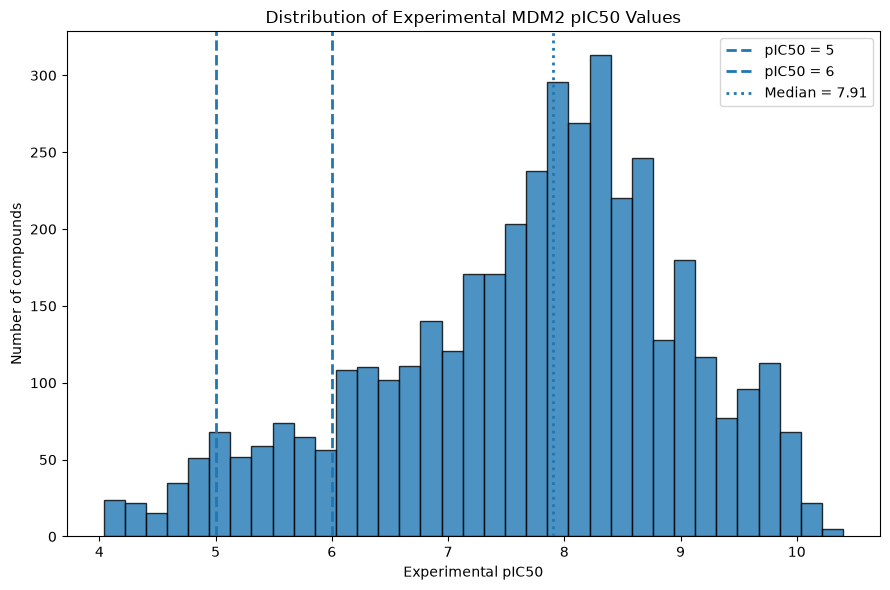

In [19]:
# ============================================================
# STEP 11: PLOT EXPERIMENTAL pIC50 DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    df["pIC50"],
    bins=35,
    edgecolor="black",
    alpha=0.8
)

# Activity thresholds
ax.axvline(
    5.0,
    linestyle="--",
    linewidth=2,
    label="pIC50 = 5"
)

ax.axvline(
    6.0,
    linestyle="--",
    linewidth=2,
    label="pIC50 = 6"
)

# Median
ax.axvline(
    df["pIC50"].median(),
    linestyle=":",
    linewidth=2,
    label=f"Median = {df['pIC50'].median():.2f}"
)

ax.set_xlabel("Experimental pIC50")
ax.set_ylabel("Number of compounds")
ax.set_title("Distribution of Experimental MDM2 pIC50 Values")

ax.legend()

plt.tight_layout()
plt.show()

The experimental pIC50 distribution was concentrated mainly between approximately 7 and 9, with a median pIC50 of 7.91. The distribution showed a lower-potency tail, while relatively few compounds occurred below the predefined inactive and intermediate thresholds. This pattern was consistent with the predominance of active compounds in the dataset.

## Step 12: ACTIVITY-CLASS DISTRIBUTION


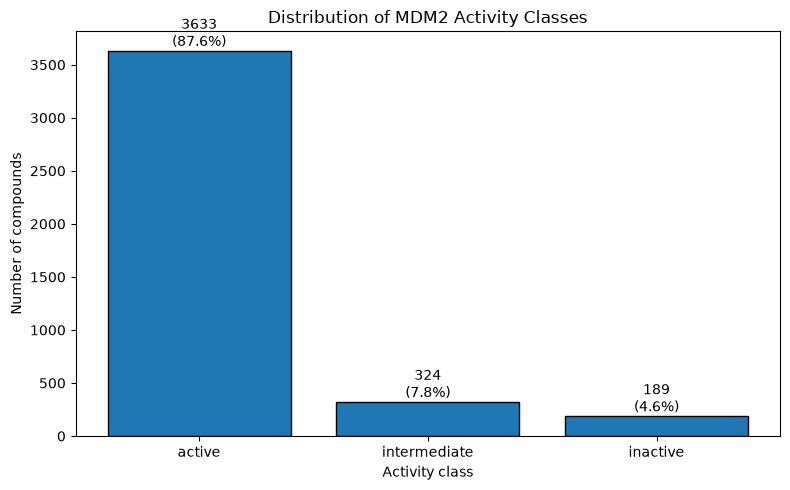

In [21]:
# ============================================================
# STEP 12: ACTIVITY-CLASS DISTRIBUTION
# ============================================================

class_order = [
    "active",
    "intermediate",
    "inactive",
]

class_counts = (
    df["bioactivity_class"]
    .value_counts()
    .reindex(class_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    class_counts.index,
    class_counts.values,
    edgecolor="black"
)

ax.set_xlabel("Activity class")
ax.set_ylabel("Number of compounds")
ax.set_title("Distribution of MDM2 Activity Classes")

# Add count and percentage labels above bars
total = len(df)

for bar, count in zip(bars, class_counts.values):

    percentage = 100 * count / total

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Step 13:PARSE STANDARDIZED SMILES WITH RDKIT

In [25]:
# ============================================================
# STEP 13: PARSE STANDARDIZED SMILES WITH RDKIT
# ============================================================

from rdkit import Chem

df["mol"] = df["standardized_smiles"].apply(
    Chem.MolFromSmiles
)

invalid_molecules = df["mol"].isna().sum()

print("Total compounds:", len(df))
print("RDKit parsing failures:", invalid_molecules)


Total compounds: 4146
RDKit parsing failures: 0


## Step 14: GENERATE BEMIS-MURCKO SCAFFOLDS


In [26]:
# ============================================================
# STEP 14: GENERATE BEMIS-MURCKO SCAFFOLDS
# ============================================================

from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np


def get_murcko_scaffold(mol):

    if mol is None:
        return np.nan

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    if scaffold.GetNumAtoms() == 0:
        return np.nan

    return Chem.MolToSmiles(
        scaffold,
        canonical=True
    )


df["murcko_scaffold"] = df["mol"].apply(
    get_murcko_scaffold
)

print(
    "Compounds with a Bemis-Murcko scaffold:",
    df["murcko_scaffold"].notna().sum()
)

print(
    "Compounds without a Bemis-Murcko scaffold:",
    df["murcko_scaffold"].isna().sum()
)

Compounds with a Bemis-Murcko scaffold: 4146
Compounds without a Bemis-Murcko scaffold: 0


## Step 15: SCAFFOLD DIVERSITY SUMMARY


In [28]:
# ============================================================
# STEP 15: SCAFFOLD DIVERSITY SUMMARY
# ============================================================

scaffold_counts = (
    df["murcko_scaffold"]
    .value_counts()
)

n_unique_scaffolds = scaffold_counts.shape[0]

print("Total compounds:", len(df))
print("Unique Bemis-Murcko scaffolds:", n_unique_scaffolds)

print(
    "Average compounds per scaffold:",
    round(len(df) / n_unique_scaffolds, 2)
)

print("\nTop 10 most frequent scaffolds:")
display(
    scaffold_counts
    .head(10)
    .to_frame("compound_count")
)

Total compounds: 4146
Unique Bemis-Murcko scaffolds: 1486
Average compounds per scaffold: 2.79

Top 10 most frequent scaffolds:


,compound_count
murcko_scaffold,
O=C1CC[C@H](c2ccccc2)[C@@H](c2ccccc2)N1,112
c1ccc(Cn2c(-c3ccccc3)nc3ncnc(NCC4CCC4)c32)cc1,100
c1ccc(Cn2c(-c3ccccc3)nc3ncnc(NCC4CC4)c32)cc1,76
O=C1c2nc(-c3cncnc3)[nH]c2C(c2ccccc2)N1c1ccccc1,57
O=C1c2nc(-c3ccccc3)[nH]c2C(c2ccccc2)N1c1ccccc1,53
O=C1c2ccccc2[C@](OCC2CC2)(c2ccccc2)N1Cc1ccccc1,51
c1ccc(Cn2c(-c3ccccn3)nc3ncnc(NCC4CCC4)c32)cc1,51
O=C1c2ccccc2C(c2ccccc2)N1Cc1ccccc1,48
O=C1CC[C@H](c2ccccc2)[C@@H](c2ccccc2)N1CC1CC1,46


## Step 16: SINGLETON SCAFFOLDS


In [29]:
# ============================================================
# STEP 16: SINGLETON SCAFFOLDS
# ============================================================

n_singleton_scaffolds = (
    scaffold_counts == 1
).sum()

singleton_scaffold_percentage = (
    100 * n_singleton_scaffolds / n_unique_scaffolds
)

singleton_compound_percentage = (
    100 * n_singleton_scaffolds / len(df)
)

print("Singleton scaffolds:", n_singleton_scaffolds)

print(
    "Percentage of unique scaffolds that are singletons:",
    f"{singleton_scaffold_percentage:.2f}%"
)

print(
    "Percentage of compounds belonging to singleton scaffolds:",
    f"{singleton_compound_percentage:.2f}%"
)

Singleton scaffolds: 957
Percentage of unique scaffolds that are singletons: 64.40%
Percentage of compounds belonging to singleton scaffolds: 23.08%


## Step 17: COMPOUNDS PER SCAFFOLD


In [86]:
# ============================================================
# STEP 17: TOP-SCAFFOLD COVERAGE
# ============================================================

for top_n in [1, 5, 10, 20]:

    compounds_covered = scaffold_counts.head(top_n).sum()

    coverage = 100 * compounds_covered / len(df)

    print(
        f"Top {top_n:2d} scaffolds: "
        f"{compounds_covered} compounds "
        f"({coverage:.2f}% of dataset)"
    )

Top  1 scaffolds: 112 compounds (2.70% of dataset)
Top  5 scaffolds: 398 compounds (9.60% of dataset)
Top 10 scaffolds: 635 compounds (15.32% of dataset)
Top 20 scaffolds: 942 compounds (22.72% of dataset)


## Step 18: CALCULATE BASIC PHYSICOCHEMICAL DESCRIPTORS


In [87]:
# ============================================================
# STEP 18: CALCULATE BASIC PHYSICOCHEMICAL DESCRIPTORS
# ============================================================

from rdkit.Chem import Descriptors, Crippen, Lipinski


def calculate_basic_descriptors(mol):
    return pd.Series({
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
    })


descriptor_df = df["mol"].apply(calculate_basic_descriptors)

display(descriptor_df.head())

,MW,LogP,TPSA,HBD,HBA,RotatableBonds
0,542.562,4.4206,105.40,2.0,7.0,8.0
1,534.027,5.3340,70.00,2.0,4.0,8.0
2,516.037,5.1949,70.00,2.0,4.0,8.0
3,550.026,4.3064,90.23,3.0,5.0,9.0
4,550.026,4.3064,90.23,3.0,5.0,9.0


## Step 19: ADD DESCRIPTORS TO THE MAIN DATAFRAME


In [88]:
# ============================================================
# STEP 19: ADD DESCRIPTORS TO THE MAIN DATAFRAME
# ============================================================

descriptor_columns = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
]

# Safety check
assert len(df) == len(descriptor_df), \
    "df and descriptor_df have different numbers of rows."

# Add descriptor columns to df
for col in descriptor_columns:
    df[col] = descriptor_df[col].to_numpy()

print("Descriptors added to df successfully.")

print("\nNew columns:")
print(df.columns.tolist())

display(
    df[
        ["pIC50", "bioactivity_class"] + descriptor_columns
    ].head()
)

Descriptors added to df successfully.

New columns:
['molecule_chembl_id', 'canonical_smiles', 'standardized_smiles', 'IC50_nM_median', 'pIC50', 'pIC50_mean', 'pIC50_std', 'measurement_count', 'bioactivity_class', 'mol', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds']


,pIC50,bioactivity_class,MW,LogP,TPSA,HBD,HBA,RotatableBonds
0,7.465466,active,542.562,4.4206,105.40,2.0,7.0,8.0
1,8.116422,active,534.027,5.3340,70.00,2.0,4.0,8.0
2,7.958607,active,516.037,5.1949,70.00,2.0,4.0,8.0
3,8.283997,active,550.026,4.3064,90.23,3.0,5.0,9.0
4,8.283997,active,550.026,4.3064,90.23,3.0,5.0,9.0


## Step 20: CHECK DESCRIPTOR VALUES


In [89]:
# ============================================================
# STEP 20: CHECK DESCRIPTOR VALUES
# ============================================================

print("Missing descriptor values:")

display(
    df[descriptor_columns]
    .isna()
    .sum()
    .to_frame("missing_count")
)

Missing descriptor values:


,missing_count
MW,0
LogP,0
TPSA,0
HBD,0
HBA,0
RotatableBonds,0


## BOXPLOTS + OBSERVATION UNDER EACH PLOT


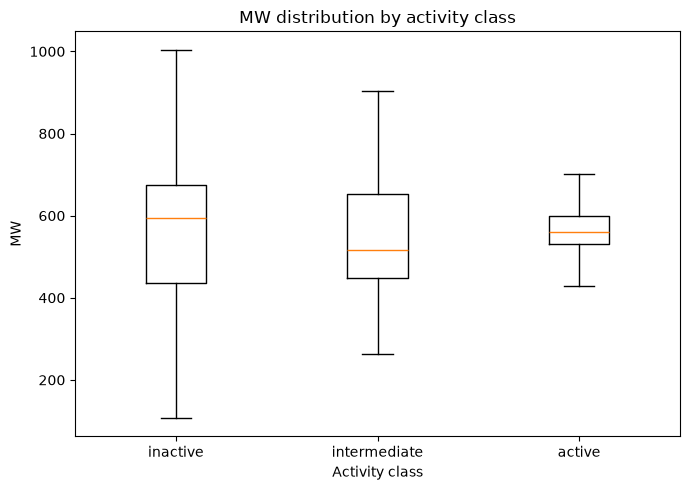

Observation: Molecular weight distributions overlap strongly across the three activity classes. Active compounds occupy a relatively narrower range, but MW alone does not clearly separate the classes.
------------------------------------------------------------------------------------------


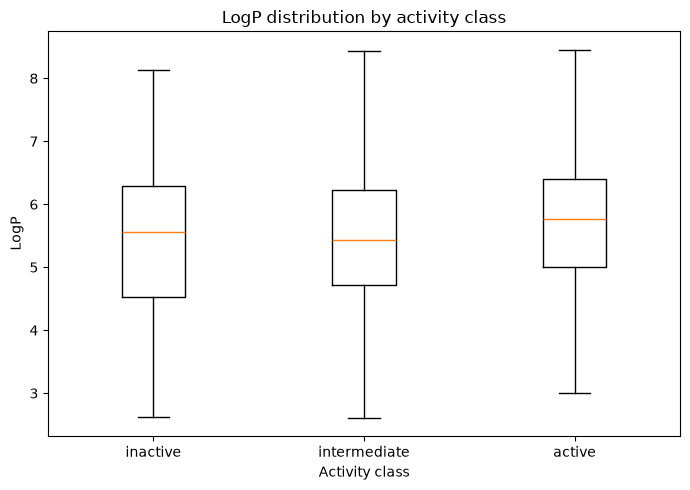

Observation: Active compounds show a slightly higher median LogP, suggesting somewhat greater lipophilicity on average. However, the substantial overlap indicates that LogP alone does not distinguish activity classes.
------------------------------------------------------------------------------------------


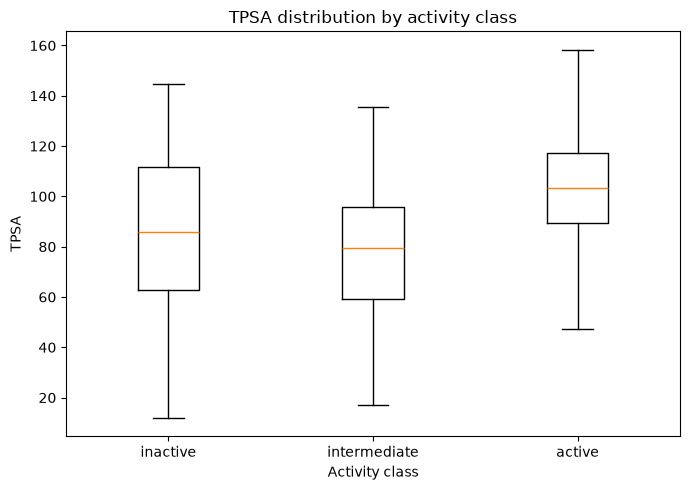

Observation: Active compounds show a somewhat higher median TPSA. However, the distributions overlap considerably, indicating that TPSA alone does not provide clear separation between activity classes.
------------------------------------------------------------------------------------------


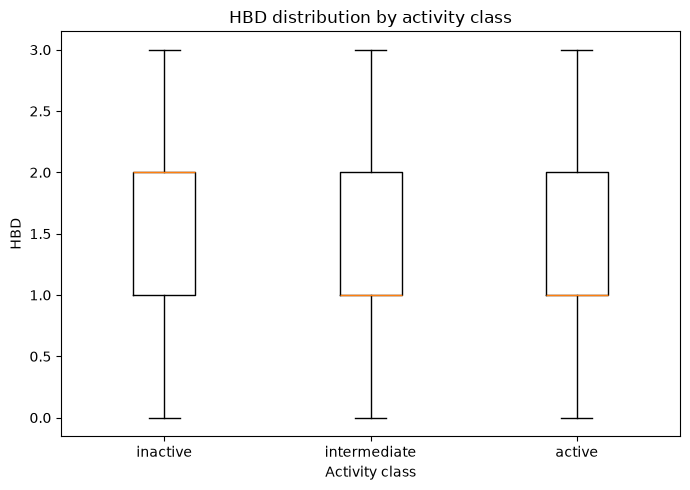

Observation: Hydrogen-bond donor counts are broadly similar across inactive, intermediate, and active compounds. HBD therefore shows limited ability to differentiate the activity classes.
------------------------------------------------------------------------------------------


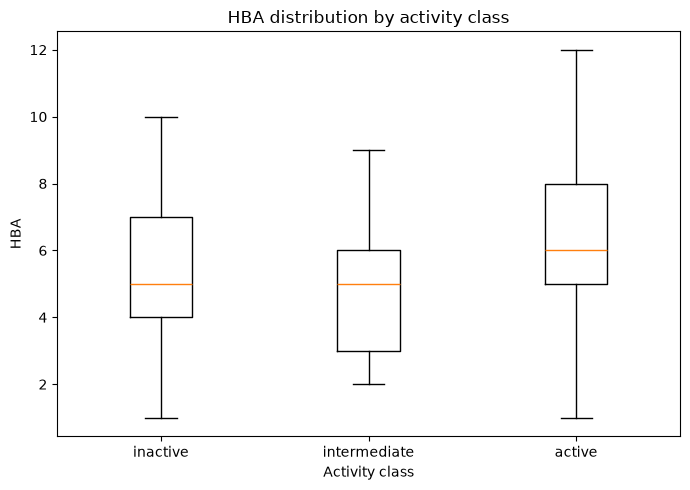

Observation: Active compounds tend to have slightly more hydrogen-bond acceptors, but considerable overlap exists between all three classes. HBA alone is therefore not sufficient for class separation.
------------------------------------------------------------------------------------------


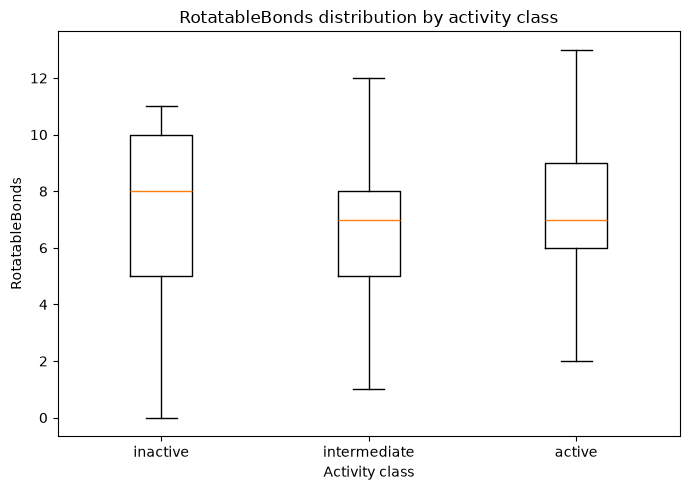

Observation: Rotatable-bond distributions are broadly similar across the activity classes, suggesting that molecular flexibility alone does not clearly distinguish active from inactive compounds.
------------------------------------------------------------------------------------------


In [82]:
# ============================================================
# BOXPLOTS + OBSERVATION UNDER EACH PLOT
# ============================================================

import matplotlib.pyplot as plt

descriptor_cols = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds"
]

class_order = [
    "inactive",
    "intermediate",
    "active"
]

observations = {
    "MW": (
        "Observation: Molecular weight distributions overlap strongly across "
        "the three activity classes. Active compounds occupy a relatively "
        "narrower range, but MW alone does not clearly separate the classes."
    ),

    "LogP": (
        "Observation: Active compounds show a slightly higher median LogP, "
        "suggesting somewhat greater lipophilicity on average. However, the "
        "substantial overlap indicates that LogP alone does not distinguish activity classes."
    ),

    "TPSA": (
        "Observation: Active compounds show a somewhat higher median TPSA. "
        "However, the distributions overlap considerably, indicating that "
        "TPSA alone does not provide clear separation between activity classes."
    ),

    "HBD": (
        "Observation: Hydrogen-bond donor counts are broadly similar across "
        "inactive, intermediate, and active compounds. HBD therefore shows "
        "limited ability to differentiate the activity classes."
    ),

    "HBA": (
        "Observation: Active compounds tend to have slightly more hydrogen-bond "
        "acceptors, but considerable overlap exists between all three classes. "
        "HBA alone is therefore not sufficient for class separation."
    ),

    "RotatableBonds": (
        "Observation: Rotatable-bond distributions are broadly similar across "
        "the activity classes, suggesting that molecular flexibility alone "
        "does not clearly distinguish active from inactive compounds."
    )
}


for descriptor in descriptor_cols:

    data_to_plot = [
        df.loc[
            df["bioactivity_class"] == cls,
            descriptor
        ].dropna()
        for cls in class_order
    ]

    plt.figure(figsize=(7, 5))

    plt.boxplot(
        data_to_plot,
        tick_labels=class_order,
        showfliers=False
    )

    plt.xlabel("Activity class")
    plt.ylabel(descriptor)
    plt.title(f"{descriptor} distribution by activity class")

    plt.tight_layout()
    plt.show()

    # Print interpretation directly below each plot
    print(observations[descriptor])
    print("-" * 90)

## CORRELATION ANALYSIS

Figures will be saved to:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/results/EDA


,MW,LogP,TPSA,HBD,HBA,RotatableBonds,pIC50
MW,1.000,-0.552,0.921,0.852,0.803,0.913,-0.048
LogP,-0.552,1.000,-0.763,-0.739,-0.680,-0.600,0.168
TPSA,0.921,-0.763,1.000,0.936,0.886,0.909,-0.072
HBD,0.852,-0.739,0.936,1.000,0.726,0.860,-0.177
HBA,0.803,-0.680,0.886,0.726,1.000,0.757,0.034
RotatableBonds,0.913,-0.600,0.909,0.860,0.757,1.000,-0.134
pIC50,-0.048,0.168,-0.072,-0.177,0.034,-0.134,1.000


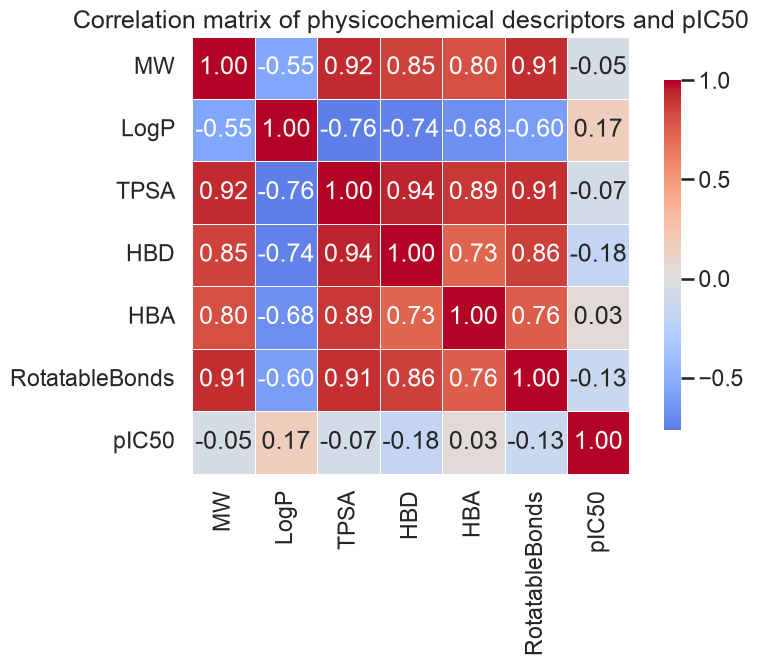

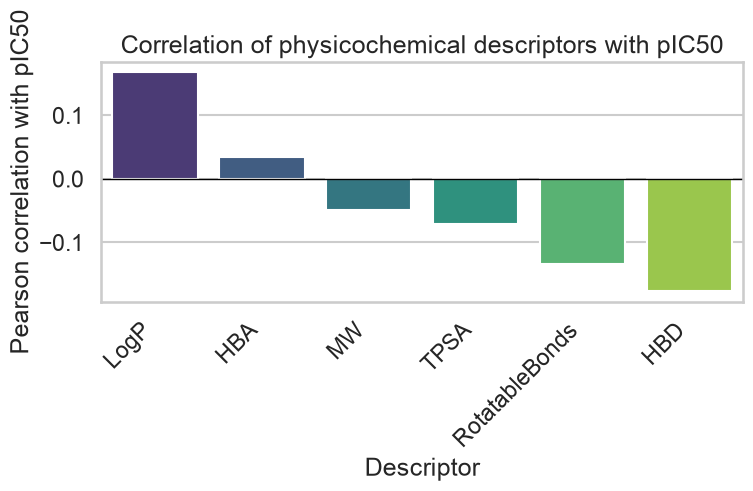

Correlation with pIC50:


,Pearson_r
LogP,0.168
HBA,0.034
MW,-0.048
TPSA,-0.072
RotatableBonds,-0.134
HBD,-0.177



Saved successfully.


In [ ]:
# ============================================================
#  CORRELATION ANALYSIS + SAVE FIGURES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
sns.set_context("talk")

descriptor_cols = [
    "MW",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds"
]

corr_cols = descriptor_cols + ["pIC50"]

# ------------------------------------------------------------
# SAVE LOCATION
# ------------------------------------------------------------

FIGURE_DIR = Path(
    "/Users/maryta/Downloads/mdm2_Reinvent_4_final/results/EDA"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Figures will be saved to:")
print(FIGURE_DIR)


# ------------------------------------------------------------
# 1. Correlation matrix
# ------------------------------------------------------------

corr_matrix = df[corr_cols].corr(method="pearson")

display(corr_matrix.round(3))


# ------------------------------------------------------------
# 2. Correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation matrix of physicochemical descriptors and pIC50"
)

plt.tight_layout()

# Save high-resolution PNG
plt.savefig(
    FIGURE_DIR / "physicochemical_pIC50_correlation_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

# Save vector PDF for thesis/paper
plt.savefig(
    FIGURE_DIR / "physicochemical_pIC50_correlation_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Correlation with pIC50 only
# ------------------------------------------------------------

pic50_corr = (
    corr_matrix["pIC50"]
    .drop("pIC50")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=pic50_corr.index,
    y=pic50_corr.values,
    hue=pic50_corr.index,
    palette="viridis",
    legend=False
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.ylabel(
    "Pearson correlation with pIC50"
)

plt.xlabel(
    "Descriptor"
)

plt.title(
    "Correlation of physicochemical descriptors with pIC50"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# Save PNG
plt.savefig(
    FIGURE_DIR / "descriptor_correlation_with_pIC50.png",
    dpi=600,
    bbox_inches="tight"
)

# Save PDF
plt.savefig(
    FIGURE_DIR / "descriptor_correlation_with_pIC50.pdf",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Print correlation values
# ------------------------------------------------------------

print("Correlation with pIC50:")

display(
    pic50_corr
    .to_frame("Pearson_r")
    .round(3)
)


# ------------------------------------------------------------
# 5. Save numerical correlation table
# ------------------------------------------------------------

corr_matrix.to_csv(
    FIGURE_DIR / "physicochemical_correlation_matrix.csv"
)

pic50_corr.to_csv(
    FIGURE_DIR / "descriptor_correlation_with_pIC50.csv",
    header=["Pearson_r"]
)

print("\nSaved successfully.")

### Correlation analysis — Observation

Pearson correlation analysis showed that none of the selected physicochemical descriptors had a strong linear relationship with pIC50.

LogP showed the largest positive correlation with pIC50 (r = 0.17), while HBD (r = -0.18) and rotatable bonds (r = -0.13) showed weak negative correlations. MW, TPSA, and HBA showed correlations close to zero.

In contrast, several physicochemical descriptors were strongly correlated with each other. For example, MW was strongly correlated with TPSA and rotatable-bond count, while TPSA was strongly correlated with HBD and HBA.

Overall, these results indicate that simple physicochemical properties alone do not explain MDM2 potency well through linear relationships. This supports the use of a multivariate QSAR model incorporating a broader set of molecular descriptors and structural fingerprints.